# Model YOLO with no prompt

## Chargement des librairies

In [1]:
import cv2
import os
import yaml
import random
import sys
import gc
import time
import pandas as pd
import numpy as np
import torch
import pickle
import json

# CUDA déterministe
os.environ.setdefault("PYTHONHASHSEED", "42")
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

from pathlib import Path
from ultralytics import YOLO
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

from utils.cv_results import normalize_and_validate_cv_results
from utils.segmentation_metrics import metrics_by_class
from utils.segmentation_visualization import (
    overlay_colored_mask,
    plot_segmentation_comparison, save_overlay_comparison,
)
from utils.yolo_metrics import (
    load_yolo_polygon_areas,
    load_yolo_polygon_instances,
    load_yolo_polygon_masks,
    instance_masks_to_yolo_lines,
    result_to_instance_areas,
    result_to_instance_masks,
    result_to_masks,
)


### Reproductibilité du code

In [2]:
# Seed global pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)
torch.set_float32_matmul_precision("highest")

# Déterminisme complet des opérations cuDNN (au prix d'un léger ralentissement)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.cuda.is_available()

True

### Choix des données

In [3]:
DATASET_NAME = "oeufs"  #  "oeufs" ou "oeufsclasses"

### Importation des données et création des chemins

In [4]:
# ------------- 1. Importation du Data Frame avec les metadata -------------
metadata = pd.read_excel("../utils/correspondance_echo_final.xlsx", dtype={"annee" : str, "image_id": str, "new_name_file": str})

# ------------- 2. Chemin des images et des labels -------------
DATASET_CONFIG = {
    "oeufs": {
        "images": "../data/YOLO/images/oeufs",
        "labels": "../data/YOLO/labels/oeufs",
        "classes": ["Oeuf"],
        "ignore_class_ids": set(),
        "group_only": True,
        "egg_class_index": 0,
        "instance_display": True,
    },
    "oeufsclasses": {
        "images": "../data/YOLO/images/oeufsclasses",
        "labels": "../data/YOLO/labels/oeufsclasses",
        "classes": ["Gonade", "Oeuf"],
        "ignore_class_ids": set(),
        "group_only": True,
        "egg_class_index": 1,
        "instance_display": True,
    },
}

dataset_config = DATASET_CONFIG[DATASET_NAME]
images_path = Path(dataset_config["images"])
labels_path = Path(dataset_config["labels"])

image_files = sorted(
    path.name for path in images_path.iterdir()
    if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

# Supprime uniquement le cache de labels correspondant à ce dataset : il peut contenir l'ancien état avec zéro annotation.
labels_cache = labels_path.with_suffix(".cache")
if labels_cache.exists():
    labels_cache.unlink()

def label_path_for_image(image_path):
    return labels_path / f"{Path(image_path).stem}.txt"

# ------------- 3. Création du répertoire des masques d'évaluation -------------
masks_dir = Path(f"masks/eval/instance/{DATASET_NAME}")
masks_dir.mkdir(parents=True, exist_ok=True)
results_dir = Path(f"results/eval/instance/{DATASET_NAME}")
results_dir.mkdir(parents=True, exist_ok=True)

### Importation des catégories des échographies

In [5]:
# -------- 4. Extraire les catégories pour chaque image --------
categories_all = []
for path in image_files:
    id_image = path.split("_")[0]
    
    matches = metadata.loc[metadata["image_id"] == id_image, "categorie"]

    if not matches.empty:
        # On prend la première valeur trouvée si des doublons existent
        cat = matches.values[0]
        categories_all.append(cat)
    else:
        # Si l'id_image n'existe pas du tout dans le fichier
        print(f"Image {id_image} introuvable dans les métadonnées.")
        categories_all.append(None)

### Division globale train/val - test avec poissons de test fixes

In [6]:
# ----- 5. Test commun fixe (~1/6 des poissons) -----
X = np.array(image_files, dtype=object) # Les images
groups = np.array([path.split("_")[2] for path in image_files]) # L'ID du poisson pour chaque image

# Liste figée après un tirage simple des poissons communs cavité/œufs (graine 42)
common_test_fish = json.loads((Path("../utils/common_test_fish.json")).read_text())
test_mask = np.isin(groups, list(common_test_fish))
if not test_mask.any():
    raise ValueError(f"Aucun poisson test commun présent dans {DATASET_NAME}.")
cv_idx, test_idx = np.flatnonzero(~test_mask), np.flatnonzero(test_mask)
cv_paths, test_paths = X[cv_idx], X[test_idx]
groups_train, groups_test = groups[cv_idx], groups[test_idx]
if not dataset_config["group_only"]:
    y = np.array(categories_all)[cv_idx]


print(f"Nombre total d'images valides : {len(image_files)}")
print(f"Échantillons train/val        : {len(cv_paths)}")
print(f"Échantillons de test          : {len(test_paths)}")

# Récupère le chemin en entier
X = [str(images_path / path) for path in cv_paths]
groups = groups_train

Nombre total d'images valides : 69
Échantillons train/val        : 58
Échantillons de test          : 11


### Hyperparamètres

In [7]:
# ------- 1. Paramètres du yaml --------
nc = len(DATASET_CONFIG[DATASET_NAME]["classes"])
names = DATASET_CONFIG[DATASET_NAME]["classes"]
names_mapping = {i: name for i, name in enumerate(names)}
label_mapping = {i: i for i in range(nc)}
for ignored_class_id in dataset_config["ignore_class_ids"]:
    label_mapping[ignored_class_id] = "ignore_label"

# ------ 2. Découpage k-folds pour la cross validation --------
CV_FOLDS = 5
def get_cv_splits():
    if dataset_config["group_only"]:
        cv_splitter = GroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
        return cv_splitter.split(X, groups=groups)

    cv_splitter = StratifiedGroupKFold(n_splits=CV_FOLDS, random_state=42, shuffle=True)
    return cv_splitter.split(X, y, groups=groups)

IMAGE_SIZE = 512
TRAIN_DEVICE = 0 if torch.cuda.is_available() else "cpu"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def compute_dataset_metrics(true, preds, echelle, label_path, prediction, image_height_px=None):
    """Surfaces dans le référentiel original YOLO, avant resize interne."""
    if image_height_px is None:
        image_height_px = true.shape[-2]
    if true.shape != preds.shape:
        raise ValueError(f"Masques YOLO incompatibles : {true.shape} et {preds.shape}.")
    if float(image_height_px) != true.shape[-2]:
        raise ValueError("La hauteur de calibration doit correspondre au masque YOLO restauré.")
    egg_class_index = dataset_config["egg_class_index"]
    egg_kwargs = {}
    if egg_class_index is not None:
        egg_kwargs["egg_annotation_areas_px"] = [load_yolo_polygon_areas(
            label_path, tuple(true.shape[-2:]), class_ids=(egg_class_index,)
        )]
        egg_kwargs["egg_prediction_areas_px"] = [result_to_instance_areas(
            prediction, names, class_ids=(egg_class_index,)
        )]
    # La hauteur des masques est celle du crop original 
    metric_values = metrics_by_class(
        true=true, preds=preds, echelle=echelle, dataset_name=DATASET_NAME,
        image_height_px=image_height_px,
        **(egg_kwargs if DATASET_NAME == "oeufs" else {}),
    )
    if DATASET_NAME != "oeufsclasses":
        return metric_values

    egg_diff_surface = metrics_by_class(
        true=true[:, egg_class_index:egg_class_index + 1],
        preds=preds[:, egg_class_index:egg_class_index + 1],
        echelle=echelle, dataset_name="oeufs",
        image_height_px=image_height_px, **egg_kwargs,
    )[-1]
    diff_surface = torch.full_like(metric_values[-1], torch.nan)
    diff_surface[:, egg_class_index] = egg_diff_surface[:, 0]
    return (*metric_values[:-1], diff_surface)

def global_diff_surface_value(diff_surface):
    egg_class_index = dataset_config["egg_class_index"]
    if egg_class_index is not None:
        return diff_surface[0, egg_class_index]
    return diff_surface.sum()

def surface_unit_for_class(class_index):
    return "mm²" if class_index == dataset_config["egg_class_index"] else "cm²"

GLOBAL_SURFACE_UNIT = (
    "mm²" if dataset_config["egg_class_index"] is not None else "cm²"
)



## Entrainement et validation du modèle

In [8]:
cv_splits = list(get_cv_splits())
fold_predictions = {}
fold_validation_paths = {}
fold_times = {}

for fold, (train_index, val_index) in enumerate(cv_splits):
    print(f"\n{'='*30}\nLancement du Fold {fold + 1}/{CV_FOLDS}\n{'='*30}")

    cv_images = X
    # Séparer les chemins
    train_paths = [cv_images[i] for i in train_index]
    val_paths = [cv_images[i] for i in val_index]
    
    # Créer les fichiers .txt contenant les chemins
    train_txt = f'folds/train_fold_{fold}.txt'
    val_txt = f'folds/val_fold_{fold}.txt'

    with open(train_txt, 'w') as f:
        f.write('\n'.join(train_paths))
    with open(val_txt, 'w') as f:
        f.write('\n'.join(val_paths))
        
    # Créer le fichier .yaml
    yaml_data = {
        'train': train_txt,
        'val': val_txt,
        'nc': nc,
        'names': names_mapping,
        'label_mapping': label_mapping,
        'masks_dir': 'labels'
    }

    yaml_file = f'data_fold_{fold}.yaml'
    with open(yaml_file, 'w') as f:
        yaml.dump(yaml_data, f, default_flow_style=False)
        
    # -------- Entrainement du modèle --------
    # Initialisation
    model = YOLO("yolo26l-seg.pt")
    
    # Entraînement
    train_start = time.perf_counter()
    model.train(data=yaml_file, epochs=100, patience = 10, lr0 = 0.0001,
            hsv_h=0.0,
            hsv_s=0.0,
            hsv_v=0.4, #0.4
            degrees=20, #20
            translate=0.2, #0.2
            scale=0.2, #0.2
            fliplr=0.0,
            mosaic=0.0,
            erasing=0.0,
            auto_augment=None,
            box=15.0,
            cls=0.3,
            imgsz=IMAGE_SIZE,
            name = "train_" + DATASET_NAME + "_instance_fold_" + str(fold + 1), # Rennomage des résultats
            exist_ok = True, # Ecrase le fichier si il existe déjà
            seed=SEED,
            deterministic=True,
            workers=0,
            cache=False,
            amp=False,
            device=TRAIN_DEVICE
            ) 
    fold_times[fold + 1] = time.perf_counter() - train_start
    print(f"Temps d'entraînement du Fold {fold + 1} : {fold_times[fold + 1]:.2f} secondes")
    
    # -------- Validation et prédiction du modèle --------
    print(f"\nÉvaluation du Fold {fold + 1}...")
    results = model.val(data=yaml_file, 
                        name = "val_" + DATASET_NAME + "_instance_fold_" + str(fold + 1),
                        exist_ok = True,
                        seed=SEED,
                        deterministic=True,
                        workers=0,
                        cache=False,
                        amp=False,
                        device=TRAIN_DEVICE
                        )
    preds = model.predict(source=val_paths, retina_masks=True, conf=0.3, verbose=False,
                          seed=SEED, workers=0, device=TRAIN_DEVICE, amp=False)

    # Export visuel après chaque fold : annotation à gauche, prédiction à droite.
    if len(preds) != len(val_paths):
        raise ValueError(
            f"Le fold {fold + 1} contient {len(val_paths)} images mais {len(preds)} prédictions."
        )
    for image_path, prediction in zip(val_paths, preds):
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            raise FileNotFoundError(f"Image de validation illisible ou introuvable : {image_path}")
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        label_path = label_path_for_image(image_path)
        if not label_path.is_file():
            raise FileNotFoundError(f"Annotation de validation introuvable : {label_path}")

        if dataset_config["instance_display"] and DATASET_NAME == "oeufs":
            egg_class_index = dataset_config["egg_class_index"]
            true_display = load_yolo_polygon_instances(
                label_path, image_rgb.shape[:2], class_ids=(egg_class_index,)
            )
            pred_display = np.zeros(image_rgb.shape[:2], dtype=np.int32)
            egg_masks = (
                mask for class_index, mask in result_to_instance_masks(prediction, names)
                if class_index == egg_class_index
            )
            for instance_id, instance_mask in enumerate(egg_masks, start=1):
                if instance_mask.shape != image_rgb.shape[:2]:
                    raise ValueError(
                        f"Dimensions d'instance incompatibles pour {image_path} : {instance_mask.shape}."
                    )
                pred_display[instance_mask > 0] = instance_id
        else:
            true_masks = load_yolo_polygon_masks(label_path, image_rgb.shape[:2], nc)
            pred_masks = result_to_masks(prediction, names, nc)
            if DATASET_NAME == "oeufsclasses":
                true_display = (true_masks[:1], load_yolo_polygon_instances(
                    label_path, image_rgb.shape[:2], class_ids=(1,)
                ))
                pred_egg_display = np.zeros(image_rgb.shape[:2], dtype=np.int32)
                for instance_id, instance_mask in enumerate((
                    mask for class_index, mask in result_to_instance_masks(prediction, names)
                    if class_index == 1
                ), start=1):
                    pred_egg_display[instance_mask > 0] = instance_id
                pred_display = (pred_masks[:1], pred_egg_display)
            else:
                true_display = true_masks
                pred_display = pred_masks
            if pred_masks.shape[1:] != image_rgb.shape[:2]:
                raise ValueError(
                    f"Dimensions de prédiction incompatibles pour {image_path} : {pred_masks.shape}."
                )

        comparison_kwargs = {}
        if DATASET_NAME == "oeufsclasses":
            true_display, true_instances = true_display
            pred_display, pred_instances = pred_display
            comparison_kwargs = {
                "true_instances": true_instances,
                "pred_instances": pred_instances,
            }
        save_overlay_comparison(
            results_dir / f"{Path(image_path).stem}.png",
            image_rgb, true_display, pred_display, alpha=0.4,
            dataset_name=DATASET_NAME, class_names=names,
            **comparison_kwargs,
        )
    print(f"{len(preds)} comparaisons du fold {fold + 1} exportées dans {results_dir.resolve()}")
    
    fold_name = f"fold_{fold + 1}"
    fold_predictions[fold_name] = preds
    fold_validation_paths[fold_name] = val_paths

    # ---------------------------------------------------------
    # Nettoyage de la mémoire GPU pour éviter l'erreur NVML
    # ---------------------------------------------------------
    del model
    del results
    del preds
    gc.collect()
    torch.cuda.empty_cache()

print("\nValidation croisée terminée avec succès !")


Lancement du Fold 1/5
New https://pypi.org/project/ultralytics/8.4.161 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.70 🚀 Python-3.14.4 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX A5000, 24114MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=15.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.3, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_fold_0.yaml, degrees=20, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26l-seg.pt, momentum=0.937, mosaic=0.0, multi_scal

KeyboardInterrupt: 

### Calcul des métriques

In [ ]:
# ------ Historique détaillé des métriques de validation ------
fold_history = {}

for fold_index in range(1, CV_FOLDS + 1):
    fold_name = f"fold_{fold_index}"
    fold_paths = fold_validation_paths[fold_name]
    predictions = fold_predictions[fold_name]
    fold_history[fold_name] = []
    if len(fold_paths) != len(predictions):
        raise ValueError(f"Le fold {fold_index} contient {len(fold_paths)} chemins mais {len(predictions)} prédictions.")

    for image_path, prediction in zip(fold_paths, predictions):
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Image de validation introuvable : {image_path}")
        image_height, image_width = image.shape[:2]
        label_path = label_path_for_image(image_path)
        if not label_path.exists():
            raise FileNotFoundError(f"Annotation introuvable : {label_path}")
        true_mask_np = load_yolo_polygon_masks(label_path, (image_height, image_width), nc)
        pred_mask_np = result_to_masks(prediction, names, nc)

        # -------- Export des masques au format YOLO --------
        # L'image fournie à YOLO est déjà le crop 510 x 380 : conserver
        # son repère natif, sans appliquer un second crop.
        image_stem = Path(image_path).stem
        pred_path = masks_dir / f"pred_{image_stem}.txt"
        masks_to_export = result_to_instance_masks(prediction, names)
        pred_polygons = instance_masks_to_yolo_lines(
            masks_to_export, (image_height, image_width),
        )
        pred_path.write_text(
            "\n".join(pred_polygons) + ("\n" if pred_polygons else "")
        )
        true_batch = torch.from_numpy(true_mask_np).unsqueeze(0).to(device=device, dtype=torch.bool)
        pred_batch = torch.from_numpy(pred_mask_np).unsqueeze(0).to(device=device, dtype=torch.bool)

        image_name = os.path.basename(image_path)
        scale_rows = metadata.loc[metadata["image_id"] == image_name.split("_")[0], "echelle"]
        if scale_rows.empty:
            raise ValueError(f"Échelle introuvable pour {image_name}")
        image_scale = float(scale_rows.iloc[0])

        image_intersection, image_union, image_iou, image_dice, image_precision, image_recall, image_diff_surface = compute_dataset_metrics(
            true=true_batch, preds=pred_batch,
            echelle=torch.tensor([[image_scale]], device=device, dtype=torch.float32),
            label_path=label_path, prediction=prediction,
            image_height_px=image_height,
        )
        true_area = true_batch.sum(dim=(2, 3)).float()
        pred_area = pred_batch.sum(dim=(2, 3)).float()
        empty = (true_area + pred_area) == 0
        for metric in (image_iou, image_dice, image_precision, image_recall):
            metric[empty] = 1.0

        image_metrics = {}
        for class_index, class_name in enumerate(names):
            image_metrics[class_name] = {
                "dice": float(image_dice[0, class_index].item()),
                "iou": float(image_iou[0, class_index].item()),
                "precision": float(image_precision[0, class_index].item()),
                "recall": float(image_recall[0, class_index].item()),
                "diff_surface": float(image_diff_surface[0, class_index].item()),
                "surface_unit": surface_unit_for_class(class_index),
            }

        global_intersection = image_intersection.sum()
        global_union = image_union.sum()
        global_true_area = true_area.sum()
        global_pred_area = pred_area.sum()
        image_metrics["Global"] = {
            "dice": float((2 * global_intersection / (global_true_area + global_pred_area)).item()) if global_true_area + global_pred_area > 0 else 1.0,
            "iou": float((global_intersection / global_union).item()) if global_union > 0 else 1.0,
            "precision": float((global_intersection / global_pred_area).item()) if global_pred_area > 0 else float(global_true_area == 0),
            "recall": float((global_intersection / global_true_area).item()) if global_true_area > 0 else float(global_pred_area == 0),
            "diff_surface": float(global_diff_surface_value(image_diff_surface).item()),
            "surface_unit": GLOBAL_SURFACE_UNIT,
        }

        fold_history[fold_name].append({
            "image": os.path.basename(image_path),
            "path": str(image_path),
            "metrics": image_metrics,
        })

fold_history["fold_times"] = fold_times
fold_history = normalize_and_validate_cv_results(
    fold_history, expected_folds=CV_FOLDS, expected_images=X,
)
print({fold: len(images) for fold, images in fold_history.items() if fold != "fold_times"})


### Sauvegarde des métriques

In [10]:
with open(f'saves/results_YOLO_instance_{DATASET_NAME}.pkl', 'wb') as fp:
    pickle.dump(fold_history, fp)

## Résultats validation

### Choix de l'image

In [13]:
# ----- 1. Choix de l'image à visualiser -----
# Mode historique : renseigner VIS_FOLD et VIS_INDEX.
# Mode direct : renseigner VIS_FILENAME avec le nom exact du fichier.
VIS_FILENAME = '0004585_12.05.40_356418_2019.jpg'  # Exemple : '0006273_15.00.01_406931_2022.jpg'
VIS_FOLD = 3  # Numéro du fold, entre 1 et CV_FOLDS
VIS_INDEX = 6  # Index de l'image dans le jeu de validation du fold (0 à len(val_paths)-1)

# ----- 2. Reconstruction du fold de validation ----
cv_splits = list(get_cv_splits())
print(f"Nombre de folds disponibles : {len(cv_splits)}")

if VIS_FILENAME is not None and str(VIS_FILENAME).strip():
    # Recherche exacte sur le basename, quel que soit le fold.
    requested_filename = Path(str(VIS_FILENAME).strip()).name
    filename_matches = []
    for fold_index, (_, val_indices_for_fold) in enumerate(cv_splits, start=1):
        val_indices_for_fold = np.asarray(val_indices_for_fold)
        val_paths_for_fold = [X[i] for i in val_indices_for_fold]
        for image_index, image_path in enumerate(val_paths_for_fold):
            if Path(image_path).name == requested_filename:
                filename_matches.append((fold_index, image_index, image_path))

    if not filename_matches:
        raise FileNotFoundError(
            f"Fichier introuvable dans les folds de validation : {requested_filename}"
        )
    if len(filename_matches) > 1:
        matches = [(fold, index) for fold, index, _ in filename_matches]
        raise ValueError(
            f"Plusieurs correspondances trouvées pour {requested_filename} : {matches}"
        )
    VIS_FOLD, VIS_INDEX, val_path = filename_matches[0]
    _, val_indices = cv_splits[VIS_FOLD - 1]
    val_indices = np.asarray(val_indices)
    val_paths = [X[i] for i in val_indices]
else:
    if not 1 <= VIS_FOLD <= len(cv_splits):
        raise ValueError(f"VIS_FOLD doit être compris entre 1 et {len(cv_splits)}.")

    _, val_indices = cv_splits[VIS_FOLD - 1]
    val_indices = np.asarray(val_indices)
    val_paths = [X[i] for i in val_indices]

    if not 0 <= VIS_INDEX < len(val_paths):
        raise IndexError(
            f"VIS_INDEX doit être compris entre 0 et {len(val_paths) - 1} "
            f"pour le fold {VIS_FOLD}."
        )
    val_path = val_paths[VIS_INDEX]

print(f"Fold sélectionné : {VIS_FOLD}, index : {VIS_INDEX}")
print(f"Nombre d'images dans le fold {VIS_FOLD}: {len(val_paths)}")

checkpoint_path = Path(
    f"runs/segment/train_{DATASET_NAME}_instance_fold_{VIS_FOLD}/weights/best.pt"
)
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint introuvable : {checkpoint_path}")

Nombre de folds disponibles : 5
Fold sélectionné : 3, index : 1
Nombre d'images dans le fold 3: 10


### Visualisation des résultats

Image : 0004585_12.05.40_356418_2019.jpg


,dice,iou,precision,recall,diff_surface,unité surface
classe,,,,,,
Oeuf,0.6343,0.4645,0.5455,0.7578,0.8600,mm²
Global,0.6343,0.4645,0.5455,0.7578,0.8600,mm²


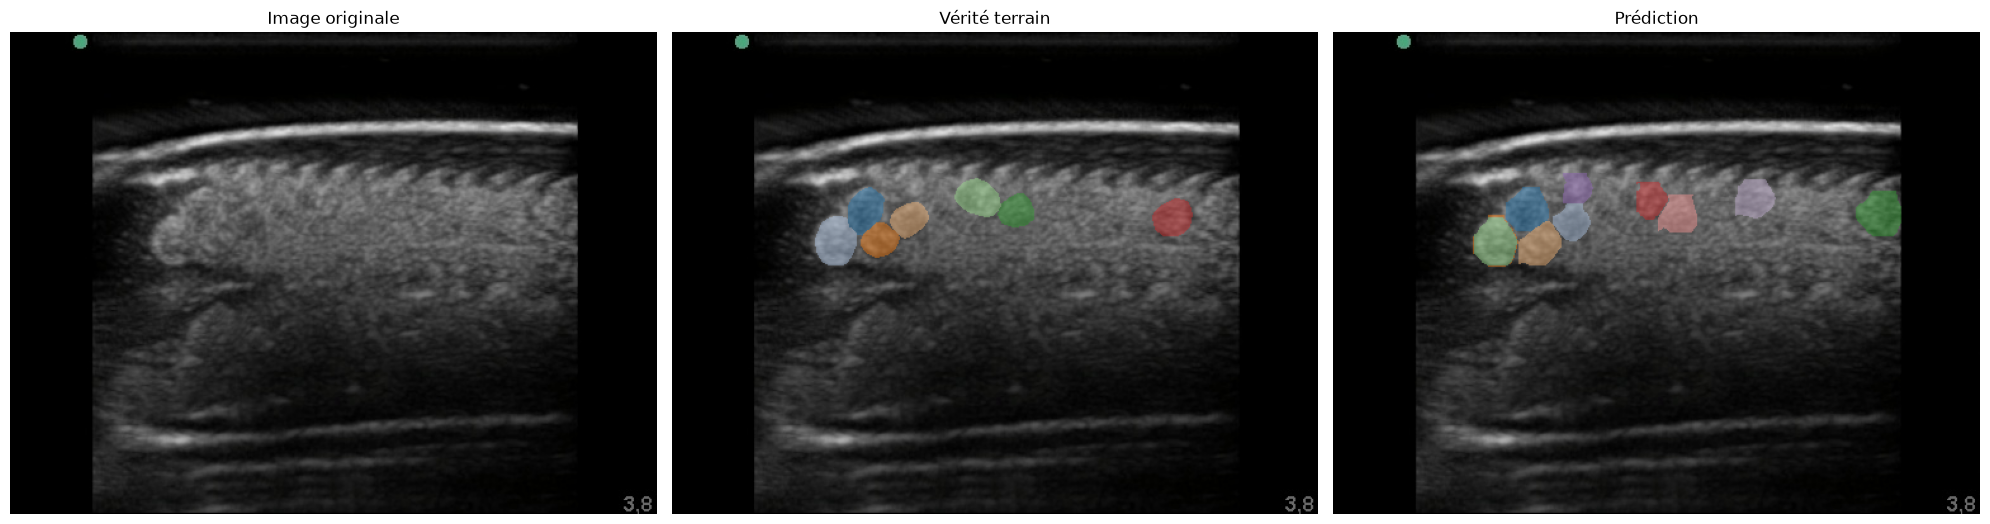

(<Figure size 2000x800 with 3 Axes>,
 array([<Axes: title={'center': 'Image originale'}>, <Axes: title={'center': 'Vérité terrain'}>, <Axes: title={'center': 'Prédiction'}>], dtype=object))

In [ ]:
# Affichage des figures dans le notebook
%matplotlib inline

# Chemin du masque correspondant à l'image
mask_path = label_path_for_image(val_path)

# ----- 1. Chargement de l'image -----
img_bgr = cv2.imread(val_path)
H_orig, W_orig, _ = img_bgr.shape

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Conversion de l'image en tenseur
image_tensor = torch.tensor(img_rgb).permute(2, 0, 1).float() / 255.0
_, H, W = image_tensor.shape

# ----- 3. Chargement du checkpoint et prédiction -----
model_eval = YOLO(str(checkpoint_path))
predictions = model_eval.predict(
    source=val_path, retina_masks=True, conf=0.4, verbose=False,
    seed=SEED, workers=0, device=TRAIN_DEVICE, amp=False,
)
preds = predictions[0]

# Conversion de la sortie YOLO en canaux dans l'ordre des classes du dataset
p_mask = result_to_masks(preds, names, nc)

# ----- 4. Récupération du masque réel -----
if not os.path.exists(mask_path):
    print(f"Attention : Aucun label trouvé à {mask_path}, un masque vide sera utilisé.")
t_mask_np = load_yolo_polygon_masks(
    mask_path,
    (H_orig, W_orig),
    nc,
)

# Cartes d'identifiants réservées à l'affichage : les métriques restent binaires.
if dataset_config["instance_display"] and DATASET_NAME == "oeufs":
    # Pour les jeux contenant des œufs, la visualisation finale affiche
    # chaque œuf séparément et exclut les autres classes (dont la gonade).
    egg_class_index = dataset_config["egg_class_index"]
    t_display_mask = load_yolo_polygon_instances(
        mask_path, (H_orig, W_orig), class_ids=(egg_class_index,)
    )
    p_display_mask = np.zeros((H_orig, W_orig), dtype=np.int32)
    egg_instances = (
        instance_mask
        for class_index, instance_mask in result_to_instance_masks(preds, names)
        if class_index == egg_class_index
    )
    for instance_id, instance_mask in enumerate(egg_instances, start=1):
        p_display_mask[instance_mask > 0] = instance_id
else:
    t_display_mask = t_mask_np
    p_display_mask = p_mask


# ----- 5. Formatage des tenseurs -----
# metrics_by_class attend des tenseurs booléens de forme [B, C, H, W] : ajoute une dimension "Batch" (B=1) avec unsqueeze(0)
true_tensor = torch.from_numpy(t_mask_np).unsqueeze(0).to(device=device, dtype=torch.bool)
preds_tensor = torch.from_numpy(p_mask).unsqueeze(0).to(device=device) > 0.5 

# ----- 6. Récupération de l'échelle ------
file_name = os.path.basename(val_path)
scale_rows = metadata.loc[metadata["image_id"] == file_name.split("_")[0], "echelle"]
if scale_rows.empty:
    raise ValueError(f"Échelle introuvable pour {file_name}")
scale = float(scale_rows.iloc[0])

scale_tensor = torch.tensor([[scale]], device=device, dtype=torch.float32)

# ------ 7. Calcul des métriques -------
intersection, union, iou, dice, precision, recall, diff_surface = compute_dataset_metrics(
    true=true_tensor, 
    preds=preds_tensor, 
    echelle=scale_tensor,
    label_path=mask_path, prediction=preds,
    image_height_px=H_orig,
)

# Correction du cas où le masque prédit et le masque réel sont vides
true_area = true_tensor.sum(dim=(2, 3)).float()
pred_area = preds_tensor.sum(dim=(2, 3)).float()
empty = (true_area + pred_area) == 0
for metric in (iou, dice, precision, recall):
    metric[empty] = 1.0

# ----- 8. Affichage des métriques -----
print(f"Image : {os.path.basename(val_path)}")

metric_rows = []
for class_idx, class_name in enumerate(names):
    metric_rows.append({
        "classe": class_name,
        "dice": dice[0, class_idx].item(),
        "iou": iou[0, class_idx].item(),
        "precision": precision[0, class_idx].item(),
        "recall": recall[0, class_idx].item(),
        "diff_surface": diff_surface[0, class_idx].item(),
        "unité surface": surface_unit_for_class(class_idx),
    })

intersection_global = intersection.sum()
union_global = union.sum()
true_global = true_area.sum()
pred_global = pred_area.sum()
metric_rows.append({
    "classe": "Global",
    "dice": (2 * intersection_global / (true_global + pred_global)).item() if true_global + pred_global > 0 else 1.0,
    "iou": (intersection_global / union_global).item() if union_global > 0 else 1.0,
    "precision": (intersection_global / pred_global).item() if pred_global > 0 else float(true_global == 0),
    "recall": (intersection_global / true_global).item() if true_global > 0 else float(pred_global == 0),
    "diff_surface": global_diff_surface_value(diff_surface).item(),
    "unité surface": GLOBAL_SURFACE_UNIT,
})

metrics_table = pd.DataFrame(metric_rows).set_index('classe')
display(metrics_table.style.format(precision=4))

# ------ 9. Affichage de l'image, du masque vrai et de la prédiction -------
plot_segmentation_comparison(
    image= image_tensor,
    mask_true=torch.tensor(t_display_mask),
    mask_pred=torch.tensor(p_display_mask),
    is_eggs=dataset_config["instance_display"],
    alpha=0.45
)

## Prédiction des résultats : échantillon de test

### Re-entrainement sur toutes les données avec les mêmes paramètres - sans validation

In [9]:
# ----- 1. Nombre d'epochs du modèle final : médiane des meilleurs epochs des folds -----
# La fitness utilisée ici reprend la pondération Ultralytics pour la segmentation :
# 10 % de mAP50-95 sur les boîtes et 90 % de mAP50-95 sur les masques.
best_epochs = []
for fold_index in range(1, CV_FOLDS + 1):
    results_csv = Path(
        f"runs/segment/train_{DATASET_NAME}_instance_fold_{fold_index}/results.csv"
    )
    if not results_csv.is_file():
        raise FileNotFoundError(
            f"Résultats du fold {fold_index} introuvables : {results_csv}"
        )

    fold_results = pd.read_csv(results_csv)
    fold_results.columns = fold_results.columns.str.strip()
    required_columns = {"epoch", "metrics/mAP50-95(B)", "metrics/mAP50-95(M)"}
    missing_columns = required_columns.difference(fold_results.columns)
    if missing_columns:
        raise ValueError(
            f"Colonnes manquantes dans {results_csv} : {sorted(missing_columns)}"
        )

    fitness = (
        0.1 * fold_results["metrics/mAP50-95(B)"]
        + 0.9 * fold_results["metrics/mAP50-95(M)"]
    )
    if fitness.isna().all():
        raise ValueError(f"Aucune fitness valide dans {results_csv}.")
    # La colonne epoch commence à 0 : +1 donne le nombre réel d'epochs à exécuter.
    best_epoch = int(fold_results.loc[fitness.idxmax(), "epoch"]) + 1
    best_epochs.append(best_epoch)

FINAL_EPOCHS = int(np.floor(np.nanmean(best_epochs)))
print(f"Meilleurs epochs des folds : {best_epochs}")
print(f"Nombre d'epochs retenu pour le modèle final : {FINAL_EPOCHS}")

# ----- 2. Dataset final : toutes les images train/validation, jamais le test -----
final_train_paths = [str(Path(path)) for path in X]
test_image_paths = [str(images_path / path) for path in test_paths]
if not final_train_paths:
    raise ValueError("Le jeu d'entraînement final est vide.")
if not test_image_paths:
    raise ValueError("Le jeu de test est vide.")

train_resolved = {Path(path).resolve() for path in final_train_paths}
test_resolved = {Path(path).resolve() for path in test_image_paths}
overlap = train_resolved.intersection(test_resolved)
if overlap:
    raise ValueError(f"Fuite de données : {len(overlap)} image(s) sont dans train et test.")
if set(groups_train).intersection(set(groups_test)):
    raise ValueError("Fuite de données : au moins un poisson est dans train et test.")

final_train_txt = Path(f"folds/train_all_{DATASET_NAME}.txt")
final_train_txt.parent.mkdir(parents=True, exist_ok=True)
final_train_txt.write_text("\n".join(final_train_paths) + "\n")

final_yaml = Path(f"data_all_{DATASET_NAME}.yaml")
final_yaml_data = {
    "train": str(final_train_txt),
    # Ultralytics exige une clé val dans le YAML, même si val=False ci-dessous.
    "val": str(final_train_txt),
    "nc": nc,
    "names": names_mapping,
    "label_mapping": label_mapping,
    "masks_dir": "labels",
}
with final_yaml.open("w") as stream:
    yaml.safe_dump(final_yaml_data, stream, sort_keys=False)

# ----- 3. Entraînement final sans validation ni arrêt anticipé -----
final_run_name = f"train_{DATASET_NAME}_instance_all"
final_model = YOLO("yolo26l-seg.pt")
final_train_start = time.perf_counter()
final_model.train(
    data=str(final_yaml), epochs=FINAL_EPOCHS, patience=0, val=False, lr0=0.0001,
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.4,
    degrees=20, translate=0.2, scale=0.2, fliplr=0.0,
    mosaic=0.0, erasing=0.0, auto_augment=None,
    box=15.0, cls=0.3, imgsz=IMAGE_SIZE,
    name=final_run_name, exist_ok=True, seed=SEED, deterministic=True,
    workers=0, cache=False, amp=False, device=TRAIN_DEVICE,
)
final_training_time = time.perf_counter() - final_train_start
final_checkpoint = Path("runs/segment") / final_run_name / "weights/last.pt"
if not final_checkpoint.is_file():
    raise FileNotFoundError(f"Checkpoint final introuvable : {final_checkpoint}")
print(f"Entraînement final terminé en {final_training_time:.2f} secondes.")
print(f"Checkpoint final : {final_checkpoint.resolve()}")

del final_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Meilleurs epochs des folds : [2, 31, 15, 12, 11]
Nombre d'epochs retenu pour le modèle final : 14
New https://pypi.org/project/ultralytics/8.4.161 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.70 🚀 Python-3.14.4 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX A5000, 24114MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=15.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.3, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_all_oeufs.yaml, degrees=20, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=14, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=

KeyboardInterrupt: 

### Lancement des prédictions à partir du nouveau checkpoints

In [10]:
# ----- 1. Prédictions du modèle final sur le jeu de test -----
if not final_checkpoint.is_file():
    raise FileNotFoundError(f"Checkpoint final introuvable : {final_checkpoint}")

test_model = YOLO(str(final_checkpoint))
test_predictions = test_model.predict(
    source=test_image_paths, retina_masks=True, conf=0.3, verbose=False,
    seed=SEED, workers=0, device=TRAIN_DEVICE, amp=False,
)
if len(test_predictions) != len(test_image_paths):
    raise RuntimeError(
        f"{len(test_image_paths)} images test fournies, mais "
        f"{len(test_predictions)} prédictions retournées par YOLO."
    )

# ----- 2. Export des masques YOLO et des comparaisons visuelles -----
# Dossier distinct des visualisations de validation croisée.
test_results_dir = Path(f"results/test/instance/{DATASET_NAME}")
test_masks_dir = Path(f"masks/test/instance/{DATASET_NAME}")
test_masks_dir.mkdir(parents=True, exist_ok=True)
test_results_dir.mkdir(parents=True, exist_ok=True)
exported_masks = 0
exported_results = 0
test_history = []

for image_path, prediction in zip(test_image_paths, test_predictions):
    image_path = Path(image_path)
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Image test illisible ou introuvable : {image_path}")
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_shape = image_rgb.shape[:2]

    label_path = label_path_for_image(image_path)
    if not label_path.is_file():
        raise FileNotFoundError(f"Annotation test introuvable : {label_path}")

    true_mask_np = load_yolo_polygon_masks(label_path, image_shape, nc)
    pred_mask_np = result_to_masks(prediction, names, nc)
    true_batch = torch.from_numpy(true_mask_np).unsqueeze(0).to(device=device, dtype=torch.bool)
    pred_batch = torch.from_numpy(pred_mask_np).unsqueeze(0).to(device=device, dtype=torch.bool)

    image_name = image_path.name
    scale_rows = metadata.loc[metadata["image_id"] == image_name.split("_")[0], "echelle"]
    if scale_rows.empty:
        raise ValueError(f"Échelle introuvable pour {image_name}")
    image_scale = float(scale_rows.iloc[0])
    image_intersection, image_union, image_iou, image_dice, image_precision, image_recall, image_diff_surface = compute_dataset_metrics(
        true=true_batch, preds=pred_batch,
        echelle=torch.tensor([[image_scale]], device=device, dtype=torch.float32),
        label_path=label_path, prediction=prediction,
        image_height_px=image_shape[0],
    )
    true_area = true_batch.sum(dim=(2, 3)).float()
    pred_area = pred_batch.sum(dim=(2, 3)).float()
    empty = (true_area + pred_area) == 0
    for metric in (image_iou, image_dice, image_precision, image_recall):
        metric[empty] = 1.0

    image_metrics = {}
    for class_index, class_name in enumerate(names):
        image_metrics[class_name] = {
            "dice": float(image_dice[0, class_index].item()),
            "iou": float(image_iou[0, class_index].item()),
            "precision": float(image_precision[0, class_index].item()),
            "recall": float(image_recall[0, class_index].item()),
            "diff_surface": float(image_diff_surface[0, class_index].item()),
            "surface_unit": surface_unit_for_class(class_index),
        }

    global_intersection = image_intersection.sum()
    global_union = image_union.sum()
    global_true_area = true_area.sum()
    global_pred_area = pred_area.sum()
    image_metrics["Global"] = {
        "dice": float((2 * global_intersection / (global_true_area + global_pred_area)).item()) if global_true_area + global_pred_area > 0 else 1.0,
        "iou": float((global_intersection / global_union).item()) if global_union > 0 else 1.0,
        "precision": float((global_intersection / global_pred_area).item()) if global_pred_area > 0 else float(global_true_area == 0),
        "recall": float((global_intersection / global_true_area).item()) if global_true_area > 0 else float(global_pred_area == 0),
        "diff_surface": float(global_diff_surface_value(image_diff_surface).item()),
        "surface_unit": GLOBAL_SURFACE_UNIT,
    }
    test_history.append({
        "image": image_name,
        "path": str(image_path),
        "metrics": image_metrics,
    })

    instance_masks = result_to_instance_masks(prediction, names)
    pred_lines = instance_masks_to_yolo_lines(instance_masks, image_shape)
    pred_path = test_masks_dir / f"pred_{image_path.stem}.txt"
    pred_path.write_text("\n".join(pred_lines) + ("\n" if pred_lines else ""))
    exported_masks += 1

    if dataset_config["instance_display"] and DATASET_NAME == "oeufs":
        egg_class_index = dataset_config["egg_class_index"]
        true_display = load_yolo_polygon_instances(
            label_path, image_shape, class_ids=(egg_class_index,)
        )
        pred_display = np.zeros(image_shape, dtype=np.int32)
        egg_masks = (
            mask for class_index, mask in instance_masks
            if class_index == egg_class_index
        )
        for instance_id, instance_mask in enumerate(egg_masks, start=1):
            if instance_mask.shape != image_shape:
                raise ValueError(
                    f"Dimensions d'instance incompatibles pour {image_path} : "
                    f"{instance_mask.shape} au lieu de {image_shape}."
                )
            pred_display[instance_mask > 0] = instance_id
        comparison_kwargs = {}
    else:
        true_masks = load_yolo_polygon_masks(label_path, image_shape, nc)
        pred_masks = result_to_masks(prediction, names, nc)
        if pred_masks.shape[1:] != image_shape:
            raise ValueError(
                f"Dimensions de prédiction incompatibles pour {image_path} : "
                f"{pred_masks.shape[1:]} au lieu de {image_shape}."
            )

        if DATASET_NAME == "oeufsclasses":
            true_display = true_masks[:1]
            true_instances = load_yolo_polygon_instances(
                label_path, image_shape, class_ids=(dataset_config["egg_class_index"],)
            )
            pred_display = pred_masks[:1]
            pred_instances = np.zeros(image_shape, dtype=np.int32)
            for instance_id, (class_index, instance_mask) in enumerate(
                (item for item in instance_masks if item[0] == dataset_config["egg_class_index"]),
                start=1,
            ):
                pred_instances[instance_mask > 0] = instance_id
            comparison_kwargs = {
                "true_instances": true_instances,
                "pred_instances": pred_instances,
            }
        else:
            true_display = true_masks
            pred_display = pred_masks
            comparison_kwargs = {}

    save_overlay_comparison(
        test_results_dir / f"{image_path.stem}.png",
        image_rgb, true_display, pred_display, alpha=0.4,
        dataset_name=DATASET_NAME, class_names=names,
        **comparison_kwargs,
    )
    exported_results += 1

if exported_masks != len(test_image_paths) or exported_results != len(test_image_paths):
    raise RuntimeError("Le nombre de fichiers exportés ne correspond pas au jeu de test.")

test_history = normalize_and_validate_cv_results(
    {"fold_1": test_history}, expected_folds=1, expected_images=test_image_paths,
)
test_metrics_path = Path("saves/") / f"results_test_YOLO_instance_{DATASET_NAME}.pkl"
test_metrics_path.parent.mkdir(parents=True, exist_ok=True)
with test_metrics_path.open("wb") as fp:
    pickle.dump(test_history, fp)

print(f"Checkpoint utilisé : {final_checkpoint.resolve()}")
print(f"{exported_masks} masques test exportés dans {test_masks_dir.resolve()}")
print(f"{exported_results} comparaisons test exportées dans {test_results_dir.resolve()}")
print(f"Métriques test sauvegardées dans {test_metrics_path.resolve()}")

del test_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

NameError: name 'final_checkpoint' is not defined

In [11]:
# ----- Tableau complet des métriques pour chaque image de test -----
test_metric_rows = []

if len(test_predictions) != len(test_image_paths):
    raise RuntimeError("Le nombre de prédictions ne correspond pas au nombre d'images test.")

for image_path, prediction in zip(test_image_paths, test_predictions):
    image_path = Path(image_path)
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Image test illisible ou introuvable : {image_path}")
    image_height, image_width = image_bgr.shape[:2]
    label_path = label_path_for_image(image_path)
    if not label_path.is_file():
        raise FileNotFoundError(f"Annotation test introuvable : {label_path}")

    true_mask_np = load_yolo_polygon_masks(label_path, (image_height, image_width), nc)
    pred_mask_np = result_to_masks(prediction, names, nc)
    true_batch = torch.from_numpy(true_mask_np).unsqueeze(0).to(device=device, dtype=torch.bool)
    pred_batch = torch.from_numpy(pred_mask_np).unsqueeze(0).to(device=device) > 0.5

    scale_rows = metadata.loc[metadata["image_id"] == image_path.name.split("_")[0], "echelle"]
    if scale_rows.empty:
        raise ValueError(f"Échelle introuvable pour {image_path.name}")
    scale_tensor = torch.tensor([[float(scale_rows.iloc[0])]], device=device, dtype=torch.float32)

    intersection, union, iou, dice, precision, recall, diff_surface = compute_dataset_metrics(
        true=true_batch, preds=pred_batch, echelle=scale_tensor,
        label_path=label_path, prediction=prediction, image_height_px=image_height,
    )
    true_area = true_batch.sum(dim=(2, 3)).float()
    pred_area = pred_batch.sum(dim=(2, 3)).float()
    empty = (true_area + pred_area) == 0
    for metric in (iou, dice, precision, recall):
        metric[empty] = 1.0

    for class_index, class_name in enumerate(names):
        test_metric_rows.append({
            "image": image_path.name,
            "classe": class_name,
            "intersection_px": int(intersection[0, class_index].item()),
            "union_px": int(union[0, class_index].item()),
            "surface_réelle_px": int(true_area[0, class_index].item()),
            "surface_prédite_px": int(pred_area[0, class_index].item()),
            "dice": dice[0, class_index].item(),
            "iou": iou[0, class_index].item(),
            "précision": precision[0, class_index].item(),
            "rappel": recall[0, class_index].item(),
            "diff_surface": diff_surface[0, class_index].item(),
            "unité_diff_surface": surface_unit_for_class(class_index),
        })

    intersection_global = intersection.sum()
    union_global = union.sum()
    true_global = true_area.sum()
    pred_global = pred_area.sum()
    test_metric_rows.append({
        "image": image_path.name,
        "classe": "Global",
        "intersection_px": int(intersection_global.item()),
        "union_px": int(union_global.item()),
        "surface_réelle_px": int(true_global.item()),
        "surface_prédite_px": int(pred_global.item()),
        "dice": (2 * intersection_global / (true_global + pred_global)).item() if true_global + pred_global > 0 else 1.0,
        "iou": (intersection_global / union_global).item() if union_global > 0 else 1.0,
        "précision": (intersection_global / pred_global).item() if pred_global > 0 else float(true_global == 0),
        "rappel": (intersection_global / true_global).item() if true_global > 0 else float(pred_global == 0),
        "diff_surface": global_diff_surface_value(diff_surface).item(),
        "unité_diff_surface": GLOBAL_SURFACE_UNIT,
    })

test_metrics_table = pd.DataFrame(test_metric_rows).set_index(["image", "classe"])
display(test_metrics_table.style.format({
    "dice": "{:.4f}", "iou": "{:.4f}",
    "précision": "{:.4f}", "rappel": "{:.4f}",
    "diff_surface": "{:.4f}",
}, na_rep="—"))

NameError: name 'test_predictions' is not defined